In [1]:
# Import necessary core libraries for the machine learning pipeline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
# Load the healthcare dataset into a pandas DataFrame for analysis
df = pd.read_csv(r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\Medical-Disease\data\medical_disease.csv')

In [4]:
# Display a preview of the dataset to understand its structure, features, and values
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [5]:
# Check for data integrity by auditing duplicate records and missing values in the dataset
print("duplicate values : ", df.duplicated().sum())
print("null values : ", df.isnull().sum())

duplicate values :  0
null values :  Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64


In [6]:
# Identify and review the distinct categories within the patient gender feature
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [7]:
# Encode the categorical feature 'Gender' into a binary numerical format for machine learning compatibility
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [8]:
# Identify and review the distinct categories within the patient smoking feature
df['Smoking'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [9]:
# Standardize the 'Smoking' text format and map the categorical values to binary labels
df['Smoking'] = df['Smoking'].str.strip().str.title().map({'No': 0, 'Yes': 1})

In [10]:
# Identify and review the distinct categories within the patient Alcohal feature
df['Alcohol'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [11]:
# Standardize the 'Alcohol' text format and map the categorical values to binary labels
df['Alcohol'] = df['Alcohol'].str.strip().str.title().map({'No': 0, 'Yes': 1})

In [12]:
# Identify and review the distinct categories within the patient PhysicalActivity feature
df['PhysicalActivity'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [13]:
# Standardize the 'PhysicalActivity' text format and map the categorical values to binary labels
df['PhysicalActivity']=df['PhysicalActivity'].str.strip().str.title().map({'Medium':2,'High':3,'Low':1})

In [14]:
# Identify and review the distinct categories within the patient FamilyHistory feature
df['FamilyHistory'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [15]:
# Standardize the 'FamilyHistory' text format and map the categorical values to binary labels
df['FamilyHistory']=df['FamilyHistory'].str.strip().str.title().map({'No':0,'Yes':1})

In [16]:
# Identify and review the distinct categories within the patient Disease feature
df['Disease'].unique()

<StringArray>
['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease', 'Diabetes']
Length: 5, dtype: str

In [17]:
# Standardize the 'Disease' text format and map the categorical values to binary labels
df['Disease']=df['Disease'].str.strip().str.title().map({'Healthy':0,'Pre-Diabetes':1,'Hypertension':2,'Heart Disease':3,'Diabetes':4})

In [18]:
# Display a preview of the dataset to verify successful categorical-to-numerical encoding
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,0,0,2,0,0
1,69,1,31.1,118,256,147,92,0,0,3,1,1
2,61,0,31.3,114,206,193,74,1,0,2,0,0
3,47,0,23.9,105,162,253,68,0,0,1,0,0
4,47,1,28.3,148,121,280,84,0,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,3,0,2
9996,84,1,29.2,142,215,145,77,0,1,3,1,2
9997,41,1,22.8,177,265,133,71,0,0,2,1,2
9998,55,1,29.0,126,241,298,57,0,0,2,1,1


In [19]:
# Separate features by dropping the target variable 'Disease' from the dataset
x = df.drop('Disease', axis=1)

In [20]:
# Display the feature matrix (independent variables) to verify the final predictor variables
x

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
0,23,1,17.5,102,177,161,88,0,0,2,0
1,69,1,31.1,118,256,147,92,0,0,3,1
2,61,0,31.3,114,206,193,74,1,0,2,0
3,47,0,23.9,105,162,253,68,0,0,1,0
4,47,1,28.3,148,121,280,84,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,3,0
9996,84,1,29.2,142,215,145,77,0,1,3,1
9997,41,1,22.8,177,265,133,71,0,0,2,1
9998,55,1,29.0,126,241,298,57,0,0,2,1


In [21]:
# Extract the target variable 'Disease' into a standalone vector (dependent variable)
y = df[['Disease']]

In [22]:
# Display the target variable vector to verify the categorical disease labels
y

,Disease
0,0
1,1
2,0
3,0
4,0
...,...
9995,2
9996,2
9997,2
9998,1


In [23]:
# Check the dimensions of the dataset to verify the total number of rows (patients) and columns (features)
df.shape

(10000, 12)

In [24]:
# View the first five rows of the dataset to inspect the initial rows of the encoded data
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,0,0,2,0,0
1,69,1,31.1,118,256,147,92,0,0,3,1,1
2,61,0,31.3,114,206,193,74,1,0,2,0,0
3,47,0,23.9,105,162,253,68,0,0,1,0,0
4,47,1,28.3,148,121,280,84,0,1,3,0,0


In [25]:
# View the last five rows of the dataset to verify data consistency across the final records
df.tail()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
9995,49,1,27.1,177,183,268,59,0,0,3,0,2
9996,84,1,29.2,142,215,145,77,0,1,3,1,2
9997,41,1,22.8,177,265,133,71,0,0,2,1,2
9998,55,1,29.0,126,241,298,57,0,0,2,1,1
9999,59,1,32.2,151,162,225,93,0,0,3,1,1


In [26]:
# Generate a comprehensive summary of the DataFrame, including column data types, non-null counts, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  int64  
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  int64  
 8   Alcohol           10000 non-null  int64  
 9   PhysicalActivity  10000 non-null  int64  
 10  FamilyHistory     10000 non-null  int64  
 11  Disease           10000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 937.6 KB


In [27]:
# Generate descriptive statistics summarizing the central tendency, dispersion, and shape of the dataset's distribution
df.describe()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,50.755300,0.501100,26.082000,135.023800,175.252000,219.313500,82.690100,0.297300,0.249400,1.901300,0.390800,0.655100
std,19.242137,0.500024,4.461098,26.249406,60.536159,57.940956,16.167628,0.457093,0.432687,0.693835,0.487954,0.988657
min,18.000000,0.000000,16.000000,90.000000,70.000000,120.000000,55.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,34.000000,0.000000,23.000000,112.000000,123.000000,169.000000,69.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,51.000000,1.000000,26.000000,135.000000,174.000000,219.000000,83.000000,0.000000,0.000000,2.000000,0.000000,0.000000
75%,67.000000,1.000000,29.100000,158.000000,227.000000,269.250000,97.000000,1.000000,0.000000,2.000000,1.000000,1.000000
max,84.000000,1.000000,44.700000,180.000000,280.000000,320.000000,110.000000,1.000000,1.000000,3.000000,1.000000,4.000000


In [28]:
# Check for duplicate records and missing (null) values to evaluate data quality
df.duplicated().sum()
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

C:\Users\rehan\AppData\Local\Temp\ipykernel_18960\3291549372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease', data=df, palette='Set2')


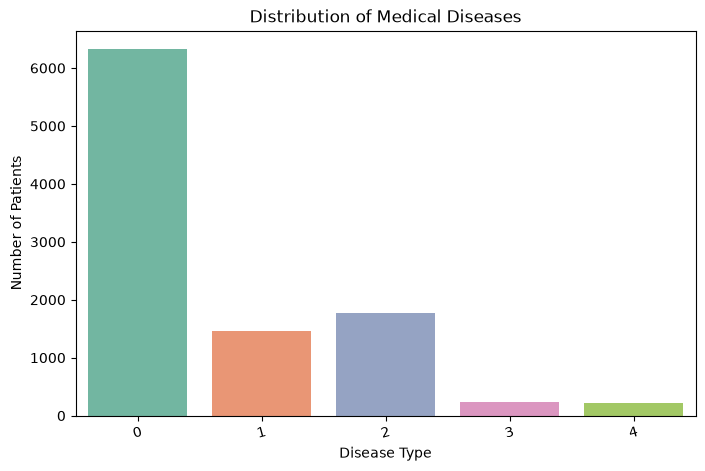

In [29]:
# Visualize the distribution of medical diseases using a count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Disease', data=df, palette='Set2')   

plt.title("Distribution of Medical Diseases")
plt.xlabel("Disease Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)
plt.show()

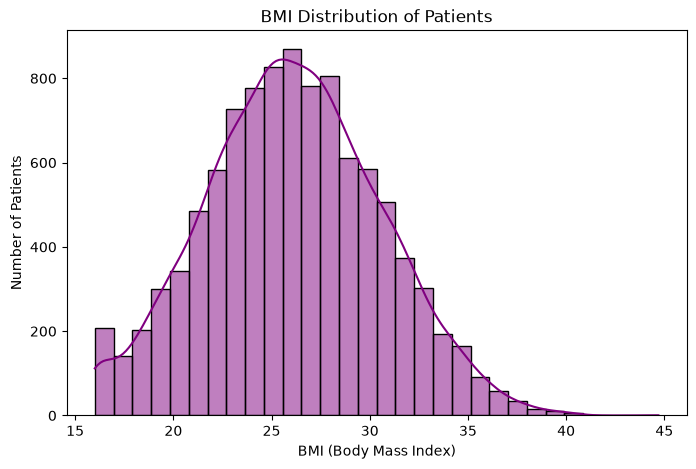

In [30]:
# Visualize the BMI distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], bins=30, kde=True, color='purple')   

plt.title("BMI Distribution of Patients")
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Number of Patients")
plt.show()

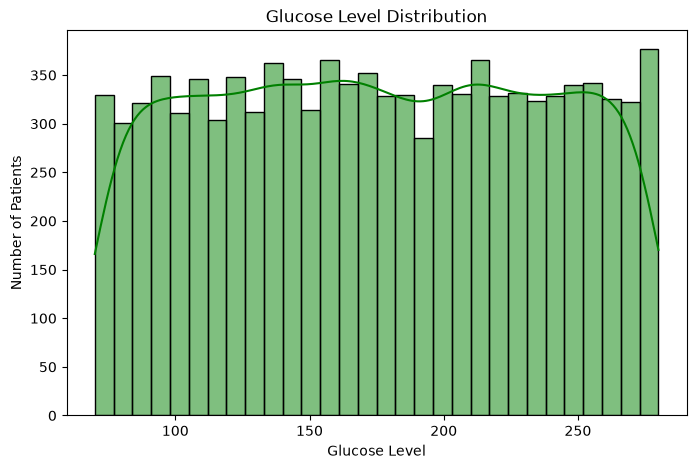

In [31]:
# Visualize the glucose level distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['GlucoseLevel'], bins=30, kde=True, color='green')   

plt.title("Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.show()

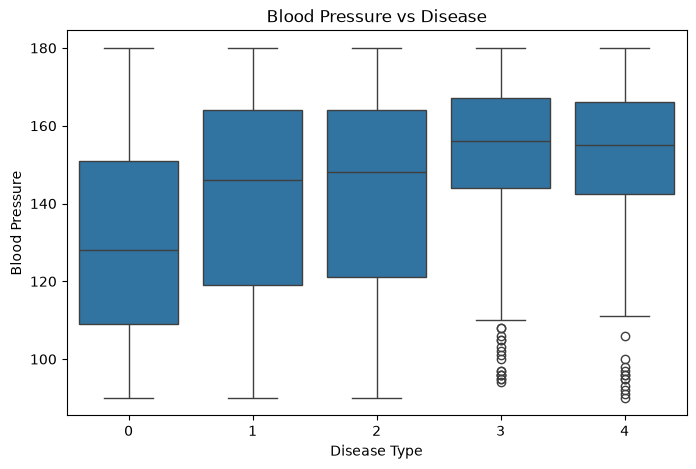

In [32]:
# Analyze the relationship between blood pressure and disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BloodPressure', data=df)

plt.title("Blood Pressure vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Blood Pressure")
plt.show()

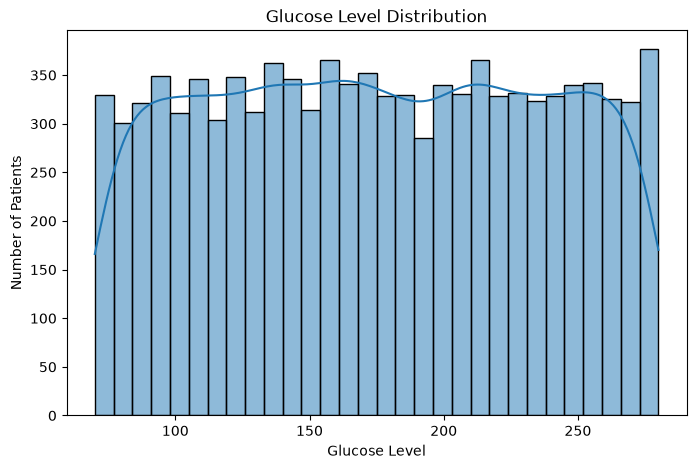

In [33]:
# Visualize the glucose level distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['GlucoseLevel'], bins=30, kde=True)

plt.title("Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.show()

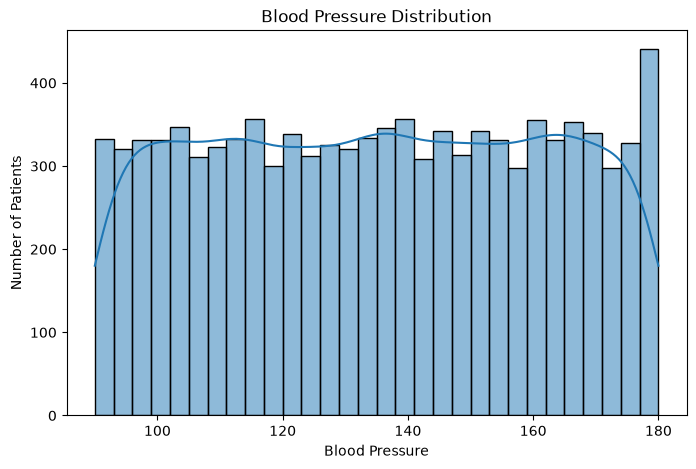

In [34]:
# Visualize the blood pressure distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['BloodPressure'], bins=30, kde=True)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

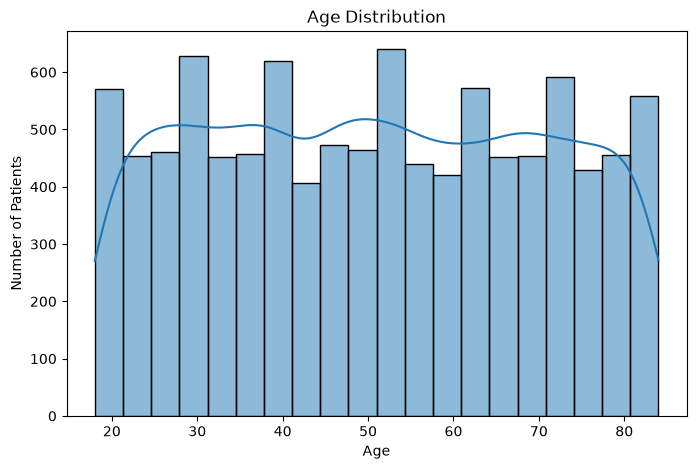

In [35]:
# Visualize the age distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

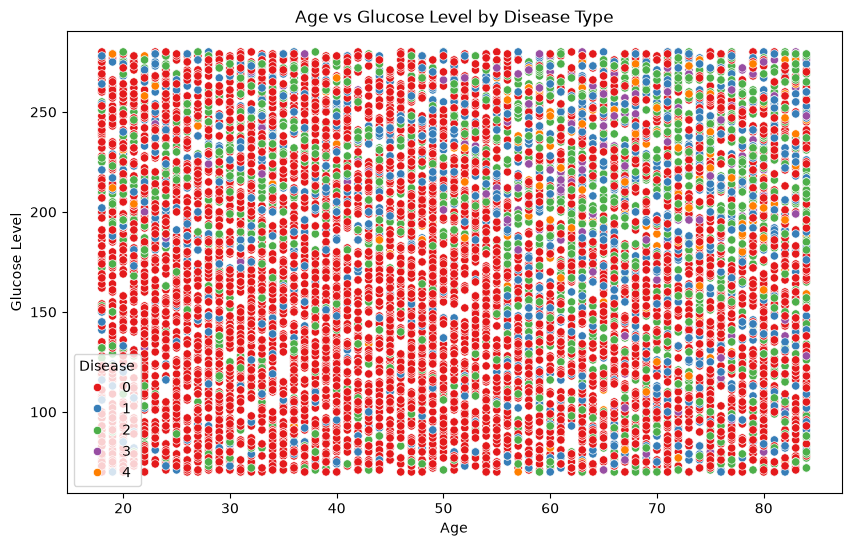

In [36]:
# Analyze the relationship between age and glucose levels across different disease types using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='GlucoseLevel', hue='Disease', data=df, palette='Set1')

plt.title("Age vs Glucose Level by Disease Type")
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.show()

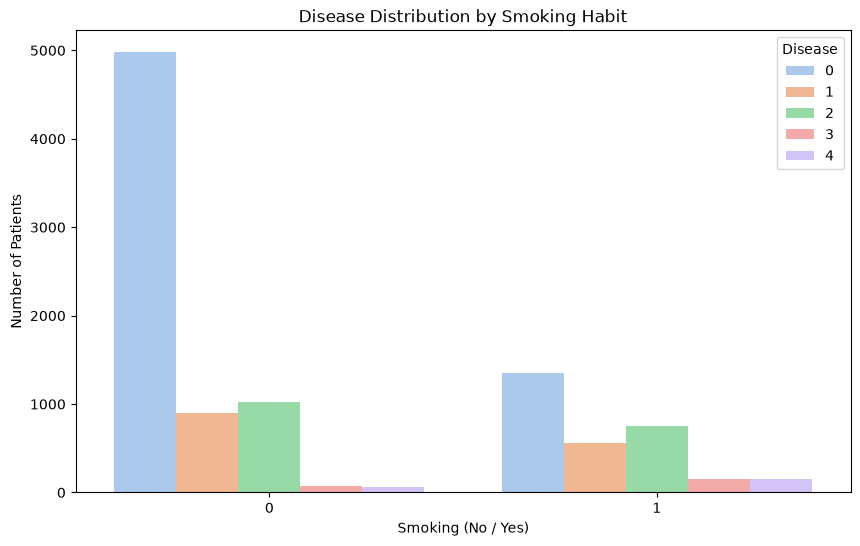

In [37]:
# Analyze the impact of smoking habits on disease distribution using a grouped count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Smoking', hue='Disease', data=df, palette='pastel')

plt.title("Disease Distribution by Smoking Habit")
plt.xlabel("Smoking (No / Yes)")
plt.ylabel("Number of Patients")
plt.show()

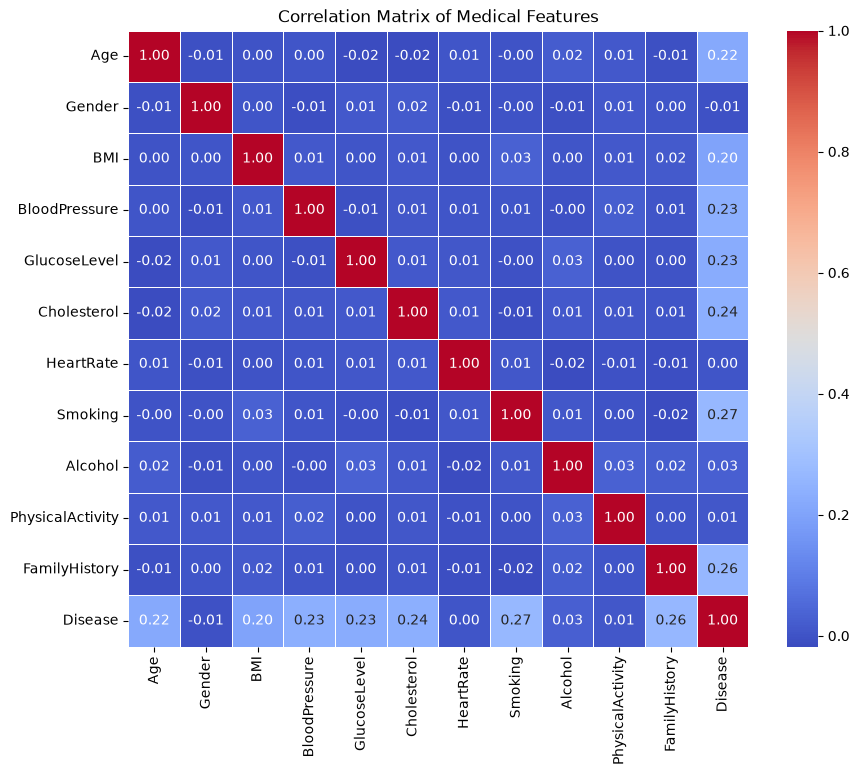

In [38]:
# Analyze the linear relationships between numeric medical features using a correlation matrix heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Matrix of Medical Features")
plt.show()

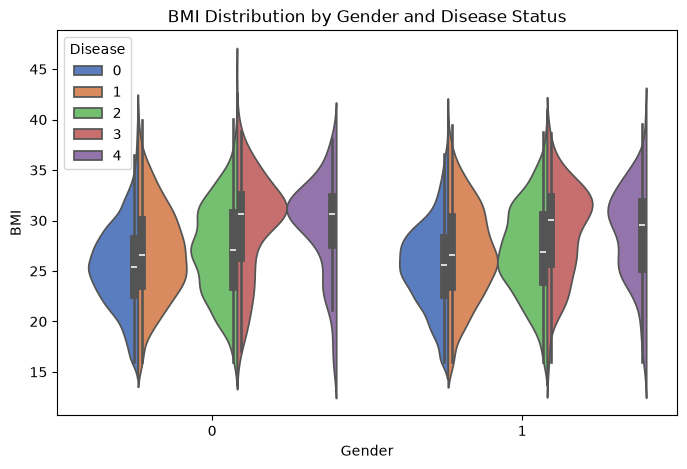

In [39]:
# Analyze BMI distribution across genders and disease status using a split violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(x='Gender', y='BMI', hue='Disease', data=df, split=True, palette='muted')

plt.title("BMI Distribution by Gender and Disease Status")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

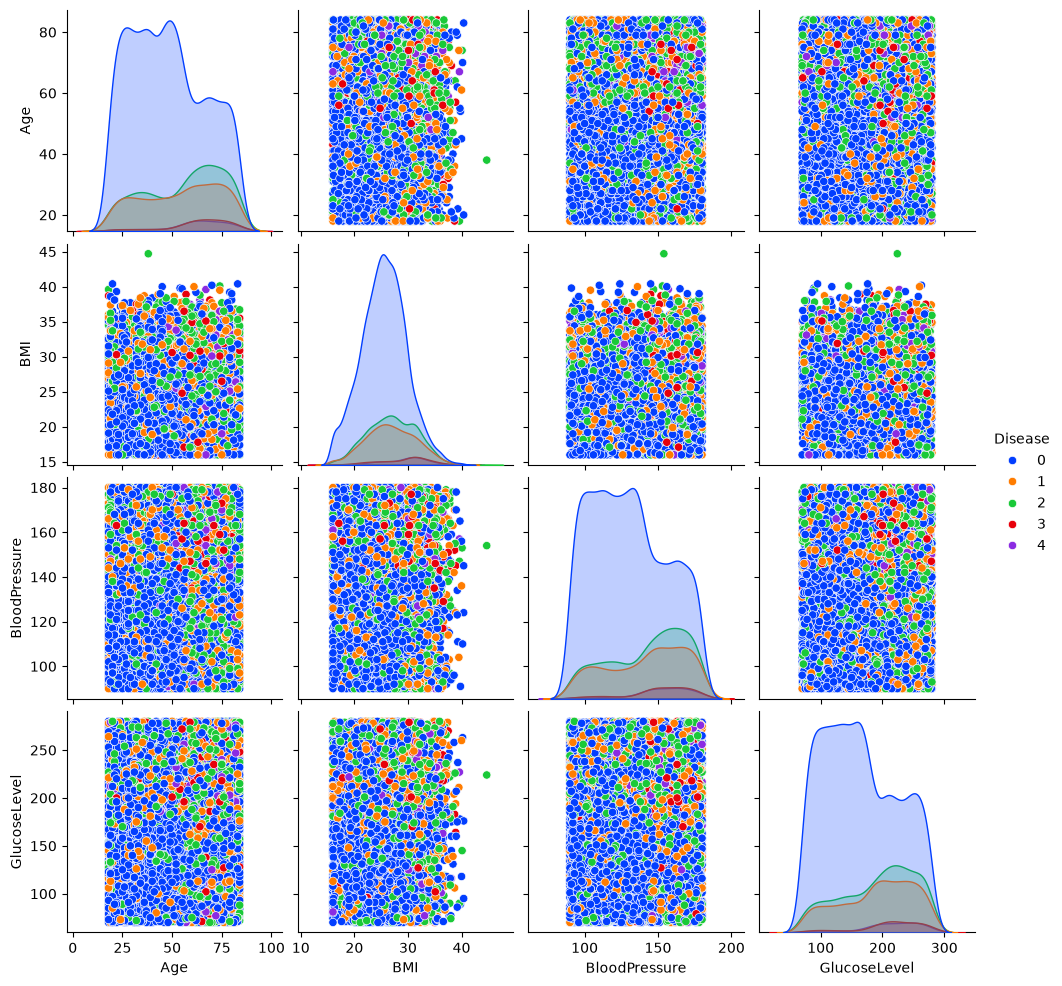

In [40]:
# Visualize pairwise relationships and distributions between key medical features across different disease types
main_features = ['Age', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Disease']
sns.pairplot(df[main_features], hue='Disease', palette='bright')

plt.show()

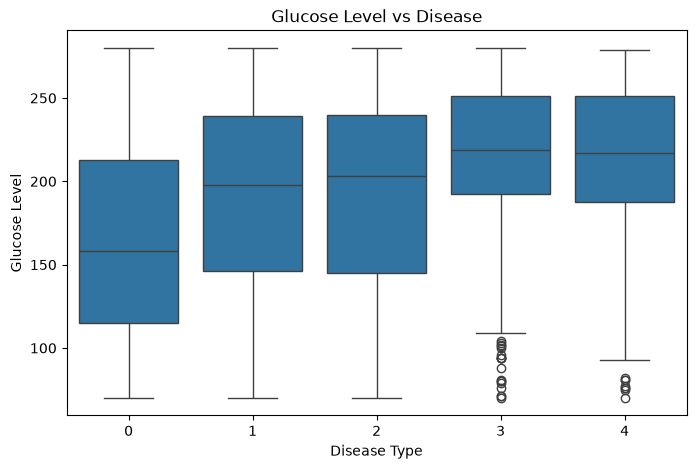

In [41]:
# Analyze the distribution and variations of glucose levels across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='GlucoseLevel', data=df)

plt.title("Glucose Level vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Glucose Level")
plt.show()

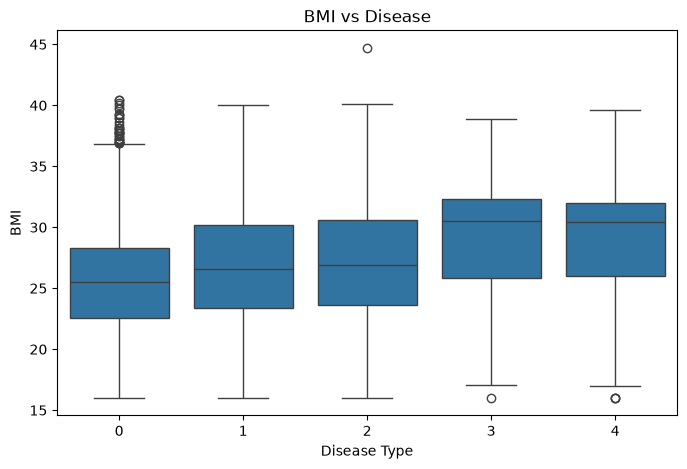

In [42]:
# Analyze the distribution and variations of BMI across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BMI', data=df)

plt.title("BMI vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("BMI")
plt.show()

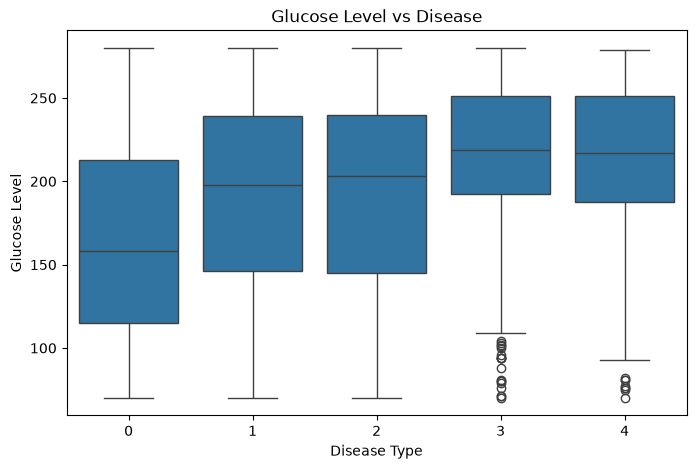

In [43]:
# Analyze the variance and median distribution of glucose levels across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='GlucoseLevel', data=df)

plt.title("Glucose Level vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Glucose Level")
plt.show()

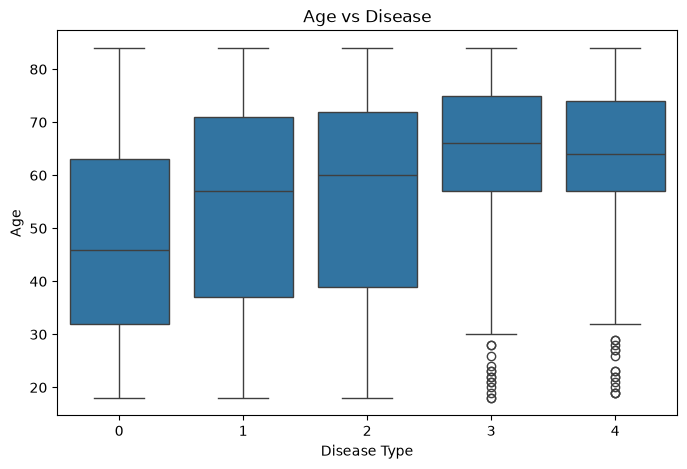

In [44]:
# Analyze the age distribution and median age variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='Age', data=df)

plt.title("Age vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Age")
plt.show()

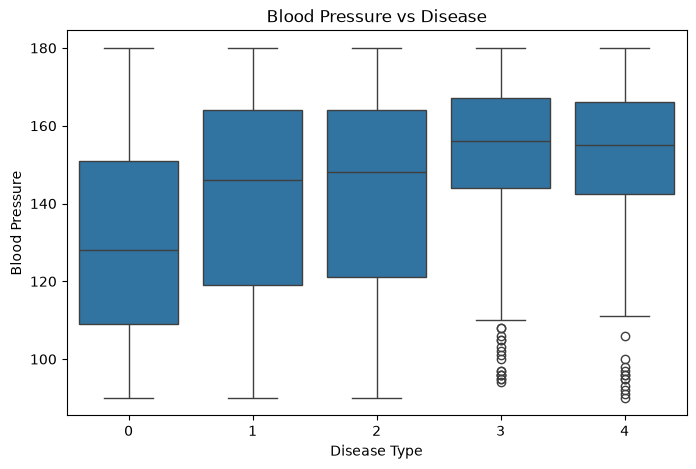

In [45]:
# Analyze the blood pressure distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BloodPressure', data=df)

plt.title("Blood Pressure vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Blood Pressure")
plt.show()

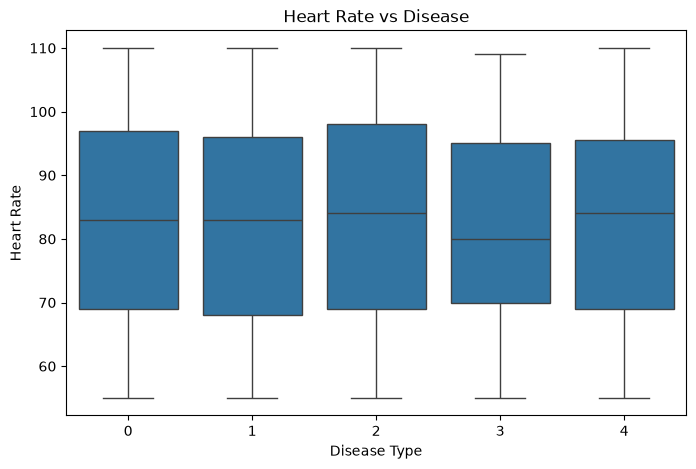

In [46]:
# Analyze the heart rate distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='HeartRate', data=df)

plt.title("Heart Rate vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Heart Rate")
plt.show()

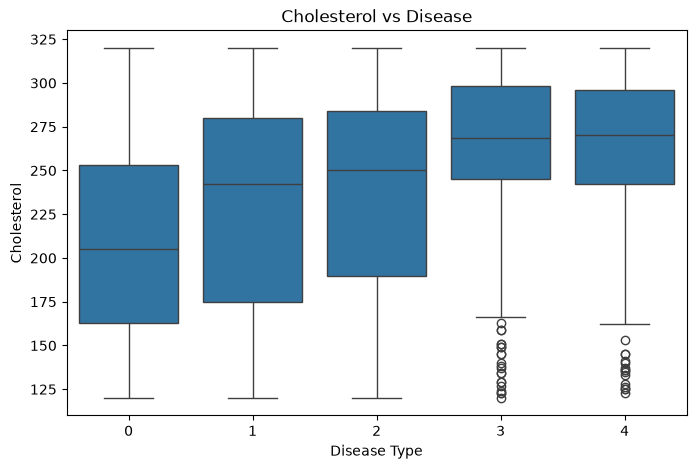

In [47]:
# Analyze the cholesterol level distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='Cholesterol', data=df)

plt.title("Cholesterol vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Cholesterol")
plt.show()

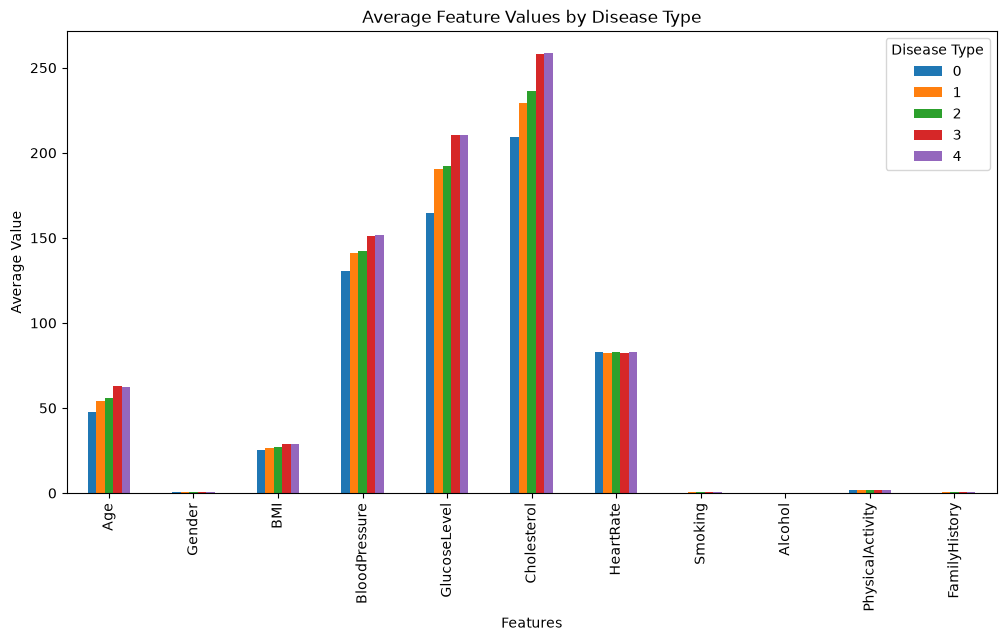

In [48]:
# Compare the average values of all numeric features across different disease types using a transposed bar chart
df.groupby('Disease').mean(numeric_only=True).T.plot(kind='bar', figsize=(12, 6))

plt.title("Average Feature Values by Disease Type")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(title="Disease Type")
plt.show()

In [49]:
# Correlation of features with target variable (Disease)
df.corr(numeric_only=True)['Disease'].sort_values(ascending=False)

Disease             1.000000
Smoking             0.266760
FamilyHistory       0.264085
Cholesterol         0.235721
BloodPressure       0.234556
GlucoseLevel        0.228177
Age                 0.217964
BMI                 0.200241
Alcohol             0.027629
PhysicalActivity    0.007958
HeartRate           0.004994
Gender             -0.005605
Name: Disease, dtype: float64

In [50]:
# Final check for missing values in dataset
df.isnull().sum().sort_values(ascending=False)

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

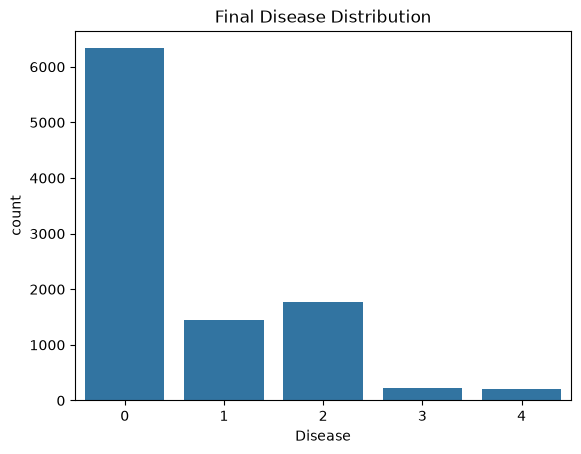

In [51]:
# Final quick view of medical disease distribution
sns.countplot(x='Disease', data=df)
plt.title("Final Disease Distribution")
plt.show()

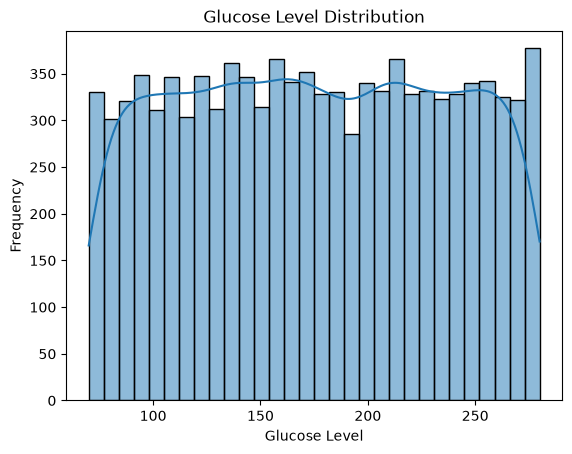

In [52]:
# Plot the distribution of the Glucose Level feature
sns.histplot(df['GlucoseLevel'], bins=30, kde=True)
plt.title('Glucose Level Distribution')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.show()

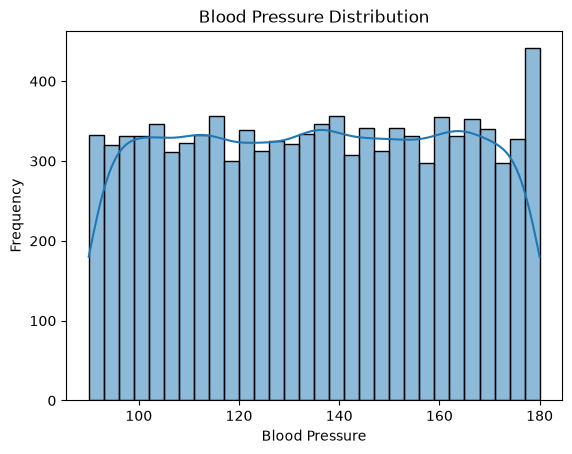

In [53]:
# Plot the distribution of the Blood Pressure feature
sns.histplot(df['BloodPressure'], bins=30, kde=True)
plt.title('Blood Pressure Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.show()

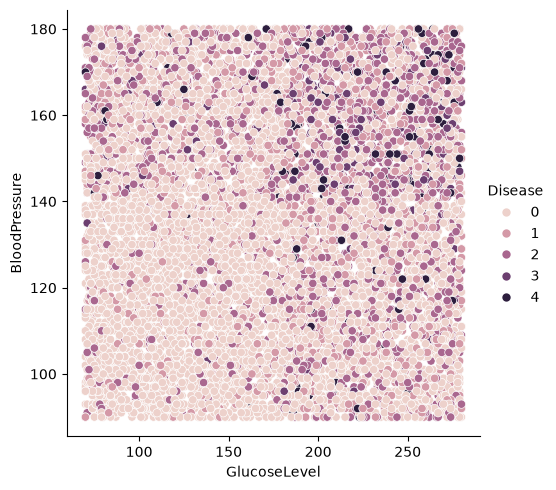

In [54]:
# Visualize the relationship between Glucose Level and Blood Pressure, with colors indicating disease status
sns.relplot(
    data=df,
    x='GlucoseLevel',
    y='BloodPressure',
    hue='Disease'
)

In [55]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [56]:
# Check the shapes of the training and testing sets
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(8000, 11) (2000, 11) (8000, 1) (2000, 1)


In [57]:
# Display the training set
x_train

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
9254,76,1,29.6,134,266,318,101,1,0,2,1
1561,35,0,29.3,96,220,300,58,0,0,1,0
1670,69,1,29.6,164,149,229,98,0,0,1,0
6087,47,1,29.0,159,250,258,109,0,1,2,0
6669,42,1,23.4,107,224,300,82,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...
5734,61,0,30.2,175,147,167,102,0,1,1,0
5191,79,0,20.5,150,225,142,84,0,0,2,1
5390,30,1,27.6,119,101,129,110,0,0,2,0
860,82,1,30.7,108,143,231,102,1,0,1,1


In [58]:
# Display the target values for the training set
y_train

,Disease
9254,2
1561,0
1670,0
6087,0
6669,0
...,...
5734,1
5191,0
5390,0
860,2


In [59]:
# Display the testing set
x_test

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
6252,36,1,23.5,122,156,146,99,0,1,2,1
4684,52,0,23.0,147,137,273,107,0,0,3,0
1731,78,1,26.3,118,128,125,55,0,0,2,1
4742,46,1,22.6,161,211,147,59,0,0,1,0
4521,64,0,27.2,126,261,162,108,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...
6412,23,0,25.5,114,204,220,99,0,0,1,0
8285,20,1,32.3,131,257,287,77,0,0,1,0
7853,53,0,26.8,180,240,306,94,0,0,3,0
1095,23,0,35.2,118,148,292,100,0,0,1,0


In [60]:
# Display the target values for the testing set
y_test

,Disease
6252,0
4684,0
1731,0
4742,0
4521,2
...,...
6412,0
8285,0
7853,2
1095,0


In [61]:
# Train a logistic regression model on the encoded training data
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [62]:
# Make predictions on the testing set using the trained model
pred=lr.predict(x_test)

In [63]:
# Display the predictions for the testing set
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [64]:
# Display the target values for the testing set
y_test

,Disease
6252,0
4684,0
1731,0
4742,0
4521,2
...,...
6412,0
8285,0
7853,2
1095,0


#### calculate the accuracy

In [65]:
# Check and print the accuracy scores for both testing and training datasets
print("accuracy of test data : ", lr.score(x_test, y_test) * 100)
print("accuracy of train data : ", lr.score(x_train, y_train) * 100)

accuracy of test data :  65.25
accuracy of train data :  64.575


#### predection

In [66]:
# Predict the target labels for the test dataset using the trained model
pred = lr.predict(x_test)

In [67]:
# Display the predicted target labels for the test dataset
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [68]:
# Display the first 5 predicted target labels from the test dataset
pred[0:5]

array([0, 0, 0, 0, 0])

#### SVM

In [69]:
# Initialize the Support Vector Classifier (SVC) for training the medical dataset
from sklearn.svm import SVC, SVR
sv_medical = SVC()

In [70]:
# Fit the Support Vector Classifier model on the training data
sv_medical.fit(x_train, y_train)

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [71]:
# Predict the target labels for the test dataset using the trained Support Vector Classifier
pred = sv_medical.predict(x_test)

In [72]:
# Display the predicted target labels generated by the Support Vector Classifier
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [73]:
# Check and print the accuracy scores for both testing and training datasets using the Support Vector Classifier
print("accuracy of test data : ", sv_medical.score(x_test, y_test) * 100)
print("accuracy of train data : ", sv_medical.score(x_train, y_train) * 100)

accuracy of test data :  63.949999999999996
accuracy of train data :  63.125
